In [1]:
import pandas as pd

df = pd.read_csv('cvd.csv')

In [2]:
df1 = pd.read_csv('10_features.csv')
X = df1.to_numpy()
y = df['DiseaseLabel'].to_numpy()

FileNotFoundError: [Errno 2] No such file or directory: '10_features.csv'

# SDFC

Epoch 10, Train Loss: 0.5310, Val Loss: 0.4436
Epoch 20, Train Loss: 0.5074, Val Loss: 0.4298
Early stopping at epoch: 30

Threshold Tuning:
Threshold 0.30: Accuracy 0.8067
Threshold 0.35: Accuracy 0.8133
Threshold 0.40: Accuracy 0.8000
Threshold 0.45: Accuracy 0.8067
Threshold 0.50: Accuracy 0.8333
Threshold 0.55: Accuracy 0.8400
Threshold 0.60: Accuracy 0.8267
Threshold 0.65: Accuracy 0.8000
Threshold 0.70: Accuracy 0.7733
Threshold 0.75: Accuracy 0.7267

Best Threshold: 0.55

Final Results:
Accuracy: 0.84

Confusion Matrix:
[[75  8]
 [16 51]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.82      0.90      0.86        83
         1.0       0.86      0.76      0.81        67

    accuracy                           0.84       150
   macro avg       0.84      0.83      0.84       150
weighted avg       0.84      0.84      0.84       150


ROC-AUC Score:
0.9091889947851106
True Positive Rate (TPR):  0.7612
False Positive Rate (FPR): 0

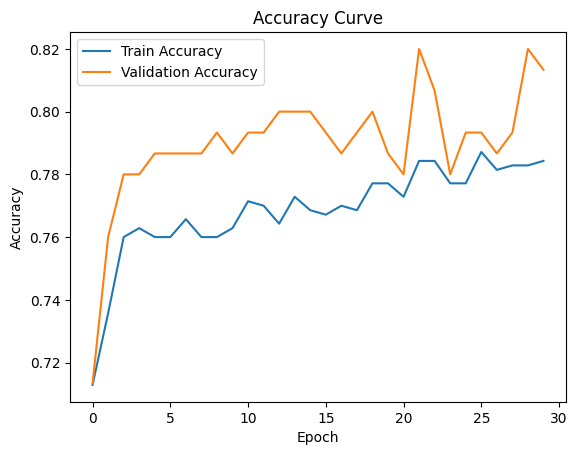

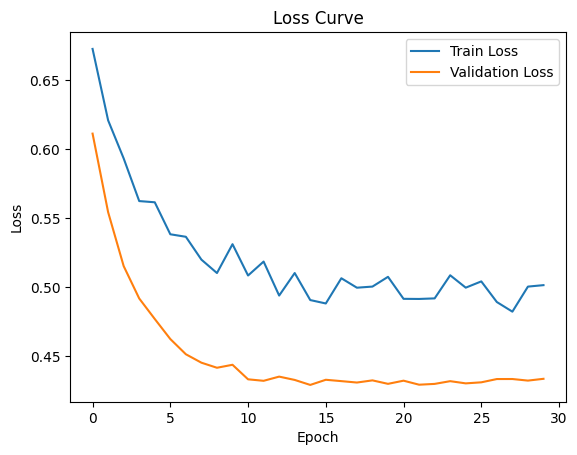

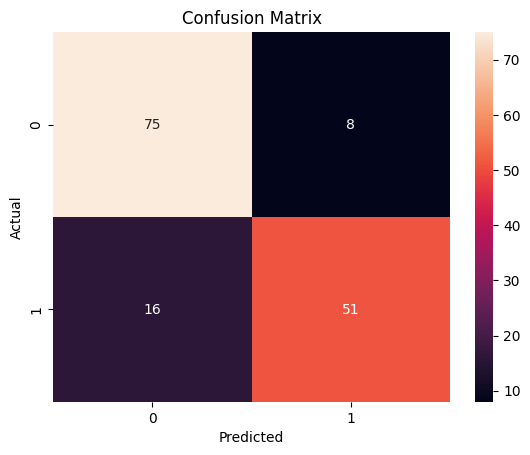

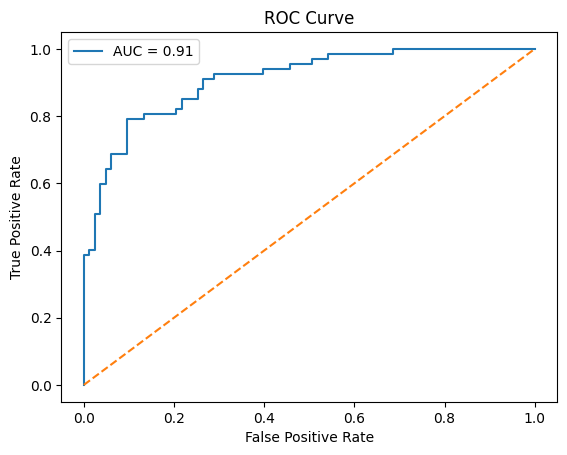

In [3]:
# =========================
# 1. Import Libraries
# =========================
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns

from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler 
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve, recall_score, precision_score, f1_score


import os

# Create results folder
results_dir = "results"
os.makedirs(results_dir, exist_ok=True)

# =========================
# 2. Load Data (Example)
# =========================
# Replace with your dataset
# df = pd.read_csv("your_dataset.csv")

# Example assumption:
# X = df.drop("target", axis=1).values
# y = df["target"].values

# =========================
# 3. Train / Val / Test Split
# =========================
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)

X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# =========================
# 4. Scaling
# =========================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

# =========================
# 5. Convert to Tensor
# =========================
X_train = torch.tensor(X_train, dtype=torch.float32)
X_val   = torch.tensor(X_val, dtype=torch.float32)
X_test  = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.float32).view(-1,1)
y_val   = torch.tensor(y_val, dtype=torch.float32).view(-1,1)
y_test  = torch.tensor(y_test, dtype=torch.float32).view(-1,1)

# =========================
# 6. DataLoader (Batching)
# =========================
train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

# =========================
class CVDModel(nn.Module):
    def __init__(self, input_size):  # ← accept input_size as parameter
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_size, 16),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.Dropout(0.4),

            nn.Linear(16, 1)   # output
        )
    def forward(self, x):
        return self.net(x)

# Instantiate with the actual number of features
model = CVDModel(input_size=X_train.shape[1])   

# =========================
# 8. Loss + Optimizer
# =========================
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

# =========================
# 9. Training (Early Stopping)
# =========================
best_val_loss = float('inf')
best_model = model.state_dict()

patience = 15
counter = 0
epochs = 100

train_acc_list = []
val_acc_list = []
train_loss_list = []
val_loss_list = []

for epoch in range(epochs):

    # -------- Train --------
    model.train()
    epoch_loss = 0

    for xb, yb in train_loader:
        outputs = model(xb)
        loss = criterion(outputs, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    train_loss = epoch_loss / len(train_loader)

    # -------- Validation --------
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_val)
        val_loss = criterion(val_outputs, y_val)

    # -------- Accuracy --------
    with torch.no_grad():
        train_probs = torch.sigmoid(model(X_train))
        train_preds = (train_probs > 0.5).float()

        val_probs = torch.sigmoid(val_outputs)
        val_preds = (val_probs > 0.5).float()

        train_acc = accuracy_score(y_train.numpy(), train_preds.numpy())
        val_acc   = accuracy_score(y_val.numpy(), val_preds.numpy())

    train_acc_list.append(train_acc)
    val_acc_list.append(val_acc)
    train_loss_list.append(train_loss)
    val_loss_list.append(val_loss.item())

    # -------- Early Stopping --------
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model = model.state_dict()
        counter = 0
    else:
        counter += 1

    if counter >= patience:
        print("Early stopping at epoch:", epoch+1)
        break

    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

# Load best model
model.load_state_dict(best_model)

# =========================
# 10. Evaluation
# =========================
model.eval()
with torch.no_grad():
    test_logits = model(X_test)
    test_probs = torch.sigmoid(test_logits)

# =========================
# 11. Threshold Tuning
# =========================
print("\nThreshold Tuning:")
thresholds = np.arange(0.3, 0.8, 0.05)

best_acc = 0
best_threshold = 0.5

for t in thresholds:
    preds = (test_probs > t).float()
    acc = accuracy_score(y_test.numpy(), preds.numpy())
    print(f"Threshold {t:.2f}: Accuracy {acc:.4f}")

    if acc > best_acc:
        best_acc = acc
        best_threshold = t

print(f"\nBest Threshold: {best_threshold:.2f}")

test_preds = (test_probs > best_threshold).float()

# =========================
# 12. Final Metrics
# =========================
print("\nFinal Results:")
print("Accuracy:", accuracy_score(y_test.numpy(), test_preds.numpy()))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test.numpy(), test_preds.numpy())
print(cm)

print("\nClassification Report:")
print(classification_report(y_test.numpy(), test_preds.numpy()))

print("\nROC-AUC Score:")
roc_auc = roc_auc_score(y_test.numpy(), test_probs.numpy())
print(roc_auc)


# Flatten the matrix to get individual components
tn, fp, fn, tp = cm.ravel()

# Sensitivity, Hit Rate, or Recall
tpr = tp / (tp + fn)

# Fall-out or Probability of False Alarm
fpr = fp / (fp + tn)

print(f"True Positive Rate (TPR):  {tpr:.4f}")
print(f"False Positive Rate (FPR): {fpr:.4f}")


precision = precision_score(y_test.numpy(), test_preds.numpy())
print(f"Precision: {precision:.4f}")

recall = recall_score(y_test.numpy(), test_preds.numpy())
print(f"Recall:    {recall:.4f}")

f1 = f1_score(y_test.numpy(), test_preds.numpy())
print(f"F1-Score:  {f1:.4f}")

# =========================
# 13. Visualization (SAVE)
# =========================

# ---- Accuracy Curve ----
plt.figure()
plt.plot(train_acc_list, label="Train Accuracy")
plt.plot(val_acc_list, label="Validation Accuracy")
plt.legend()
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.savefig(os.path.join(results_dir, "accuracy_curve.png"), dpi=300)
plt.show()


# ---- Loss Curve ----
plt.figure()
plt.plot(train_loss_list, label="Train Loss")
plt.plot(val_loss_list, label="Validation Loss")
plt.legend()
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.savefig(os.path.join(results_dir, "loss_curve.png"), dpi=300)
plt.show()


# ---- Confusion Matrix ----
plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.savefig(os.path.join(results_dir, "confusion_matrix.png"), dpi=300)
plt.show()


# ---- ROC Curve ----
fpr, tpr, _ = roc_curve(y_test.numpy(), test_probs.numpy())

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.savefig(os.path.join(results_dir, "roc_curve.png"), dpi=300)
plt.show()

Epoch 10, Train Loss: 0.4543, Val Loss: 0.4644
Early stopping at epoch: 18

Threshold Tuning:
Threshold 0.30: Accuracy 0.8400
Threshold 0.35: Accuracy 0.8200
Threshold 0.40: Accuracy 0.8200
Threshold 0.45: Accuracy 0.8400
Threshold 0.50: Accuracy 0.8200
Threshold 0.55: Accuracy 0.8067
Threshold 0.60: Accuracy 0.7867
Threshold 0.65: Accuracy 0.8000
Threshold 0.70: Accuracy 0.7733
Threshold 0.75: Accuracy 0.7667

Best Threshold: 0.30

Final Results:
Accuracy: 0.84

Confusion Matrix:
[[64 19]
 [ 5 62]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.93      0.77      0.84        83
         1.0       0.77      0.93      0.84        67

    accuracy                           0.84       150
   macro avg       0.85      0.85      0.84       150
weighted avg       0.86      0.84      0.84       150


ROC-AUC Score:
0.9163819456932206
True Positive Rate (TPR):  0.9254
False Positive Rate (FPR): 0.2289
Precision: 0.7654
Recall:    0.9254
F1-Sc

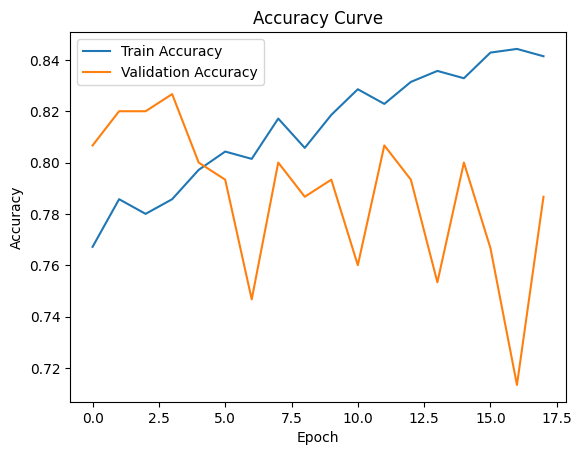

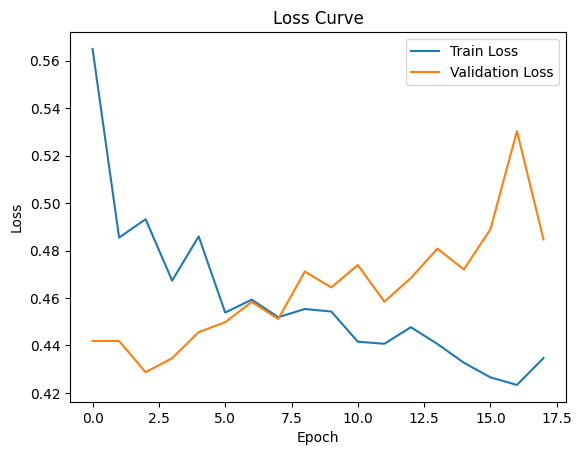

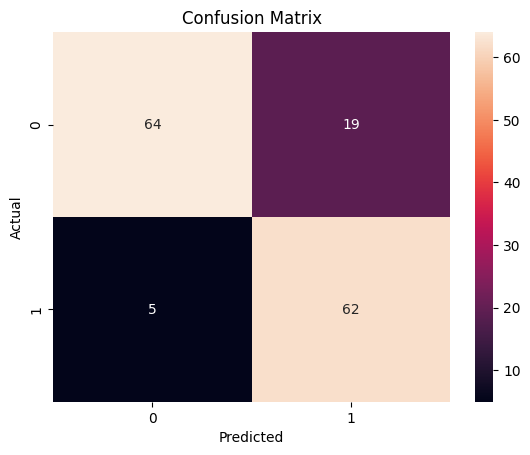

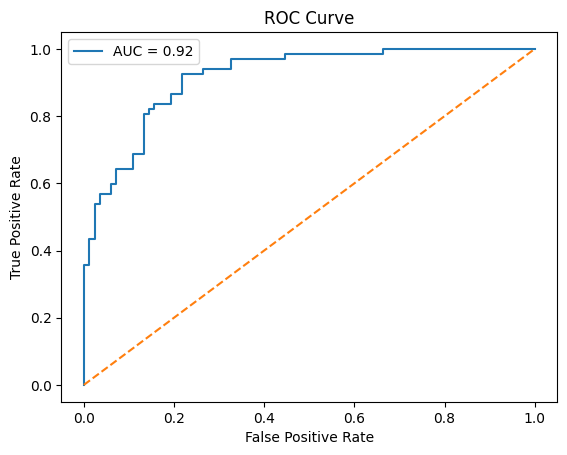

In [4]:
#=========================
# 1. Import Libraries
# =========================
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns
import torch.nn.functional as F  # Add this to your imports at the top

from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve, recall_score, f1_score, precision_score

import os

# Create results folder
results_dir = "results_0"
os.makedirs(results_dir, exist_ok=True)

# =========================
# 2. Load Data (Example)
# =========================
# Replace with your dataset
# df = pd.read_csv("your_dataset.csv")

# Example assumption:
# X = df.drop("target", axis=1).values
# y = df["target"].values

# =========================
# 3. Train / Val / Test Split
# =========================
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)

X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# =========================
# 4. Scaling
# =========================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

# =========================
# 5. Convert to Tensor
# =========================
X_train = torch.tensor(X_train, dtype=torch.float32)
X_val   = torch.tensor(X_val, dtype=torch.float32)
X_test  = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.float32).view(-1,1)
y_val   = torch.tensor(y_val, dtype=torch.float32).view(-1,1)
y_test  = torch.tensor(y_test, dtype=torch.float32).view(-1,1)

# =========================
# 6. DataLoader (Batching)
# =========================
train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

# ========================================================
# 7. HGRDIN Model Architecture (Updated)
# ========================================================


class GatedResidualBlock(nn.Module):
    def __init__(self, in_features, out_features, dropout_rate=0.25):
        super().__init__()
        
        # Main Transformation Path
        self.fc = nn.Linear(in_features, out_features)
        self.bn = nn.BatchNorm1d(out_features)
        self.dropout = nn.Dropout(dropout_rate)
        
        # Gating Mechanism
        self.gate = nn.Linear(in_features, out_features)
        
        # Shortcut connection
        self.shortcut = nn.Sequential()
        if in_features != out_features:
            self.shortcut = nn.Sequential(
                nn.Linear(in_features, out_features),
                nn.BatchNorm1d(out_features)
            )

    def forward(self, x):
        residual = self.shortcut(x)
        
        # Transformation
        out = self.fc(x)
        out = self.bn(out)
        out = F.relu(out)  # Changed from self.relu(out) to F.relu(out)
        out = self.dropout(out)
        
        # Apply Gating (Sigmoid mask)
        gate_weights = torch.sigmoid(self.gate(x))
        out = out * gate_weights
        
        # Hierarchical Interconnection
        return out + residual
# 1. Keep the GatedResidualBlock as defined
# 2. Re-add the HGRDIN wrapper class:
class HGRDIN(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.init_layer = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.BatchNorm1d(64),
            nn.ReLU()
        )
        self.block1 = GatedResidualBlock(64, 64, dropout_rate=0.2)
        self.block2 = GatedResidualBlock(64, 32, dropout_rate=0.25)
        self.block3 = GatedResidualBlock(32, 16, dropout_rate=0.3)
        self.classifier = nn.Linear(16, 1)

    def forward(self, x):
        x = self.init_layer(x)
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        return self.classifier(x)

# 3. Instantiate the wrapper:
model = HGRDIN(input_size=X_train.shape[1])

# =========================
# 8. Loss + Optimizer
# =========================
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

# =========================
# 9. Training (Early Stopping)
# =========================
best_val_loss = float('inf')
best_model = model.state_dict()

patience = 15
counter = 0
epochs = 100

train_acc_list = []
val_acc_list = []
train_loss_list = []
val_loss_list = []

for epoch in range(epochs):

    # -------- Train --------
    model.train()
    epoch_loss = 0

    for xb, yb in train_loader:
        outputs = model(xb)
        loss = criterion(outputs, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    train_loss = epoch_loss / len(train_loader)

    # -------- Validation --------
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_val)
        val_loss = criterion(val_outputs, y_val)

    # -------- Accuracy --------
    with torch.no_grad():
        train_probs = torch.sigmoid(model(X_train))
        train_preds = (train_probs > 0.5).float()

        val_probs = torch.sigmoid(val_outputs)
        val_preds = (val_probs > 0.5).float()

        train_acc = accuracy_score(y_train.numpy(), train_preds.numpy())
        val_acc   = accuracy_score(y_val.numpy(), val_preds.numpy())

    train_acc_list.append(train_acc)
    val_acc_list.append(val_acc)
    train_loss_list.append(train_loss)
    val_loss_list.append(val_loss.item())

    # -------- Early Stopping --------
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model = model.state_dict()
        counter = 0
    else:
        counter += 1

    if counter >= patience:
        print("Early stopping at epoch:", epoch+1)
        break

    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

# Load best model
model.load_state_dict(best_model)

# =========================
# 10. Evaluation
# =========================
model.eval()
with torch.no_grad():
    test_logits = model(X_test)
    test_probs = torch.sigmoid(test_logits)

# =========================
# 11. Threshold Tuning
# =========================
print("\nThreshold Tuning:")
thresholds = np.arange(0.3, 0.8, 0.05)

best_acc = 0
best_threshold = 0.5

for t in thresholds:
    preds = (test_probs > t).float()
    acc = accuracy_score(y_test.numpy(), preds.numpy())
    print(f"Threshold {t:.2f}: Accuracy {acc:.4f}")

    if acc > best_acc:
        best_acc = acc
        best_threshold = t

print(f"\nBest Threshold: {best_threshold:.2f}")

test_preds = (test_probs > best_threshold).float()

# =========================
# 12. Final Metrics
# =========================
print("\nFinal Results:")
print("Accuracy:", accuracy_score(y_test.numpy(), test_preds.numpy()))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test.numpy(), test_preds.numpy())
print(cm)

print("\nClassification Report:")
print(classification_report(y_test.numpy(), test_preds.numpy()))

print("\nROC-AUC Score:")
roc_auc = roc_auc_score(y_test.numpy(), test_probs.numpy())
print(roc_auc)

# Flatten the matrix to get individual components
tn, fp, fn, tp = cm.ravel()

# Sensitivity, Hit Rate, or Recall
tpr = tp / (tp + fn)

# Fall-out or Probability of False Alarm
fpr = fp / (fp + tn)

print(f"True Positive Rate (TPR):  {tpr:.4f}")
print(f"False Positive Rate (FPR): {fpr:.4f}")

precision = precision_score(y_test.numpy(), test_preds.numpy())
print(f"Precision: {precision:.4f}")

recall = recall_score(y_test.numpy(), test_preds.numpy())
print(f"Recall:    {recall:.4f}")

f1 = f1_score(y_test.numpy(), test_preds.numpy())
print(f"F1-Score:  {f1:.4f}")

# =========================
# 13. Visualization (SAVE)
# =========================

# ---- Accuracy Curve ----
plt.figure()
plt.plot(train_acc_list, label="Train Accuracy")
plt.plot(val_acc_list, label="Validation Accuracy")
plt.legend()
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.savefig(os.path.join(results_dir, "accuracy_curve.png"), dpi=300)
plt.show()


# ---- Loss Curve ----
plt.figure()
plt.plot(train_loss_list, label="Train Loss")
plt.plot(val_loss_list, label="Validation Loss")
plt.legend()
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.savefig(os.path.join(results_dir, "loss_curve.png"), dpi=300)
plt.show()


# ---- Confusion Matrix ----
plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.savefig(os.path.join(results_dir, "confusion_matrix.png"), dpi=300)
plt.show()


# ---- ROC Curve ----
fpr, tpr, _ = roc_curve(y_test.numpy(), test_probs.numpy())

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.savefig(os.path.join(results_dir, "roc_curve.png"), dpi=300)
plt.show()

In [5]:
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from xgboost.sklearn import XGBClassifier
from imblearn.over_sampling import SMOTE
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
import numpy as np
from sklearn.metrics          import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve
)

In [6]:
models = {
    "Logistic Regression": LogisticRegression(
        class_weight="balanced", max_iter=1000, random_state=42
    ),

    "dt":DecisionTreeClassifier(criterion='log_loss',max_depth=20),

    'gnb':GaussianNB(var_smoothing=1e-9),

    "SVM": SVC(
        kernel="rbf",
        C=0.5,                 # Lower C = more regularization (prevents overfitting)
        gamma="scale",         # Uses 1 / (n_features * X.var())
        class_weight="balanced",
        probability=True,      # Keep True only if you need ROC-AUC or soft voting
        cache_size=500,        # Uses more RAM to speed up training
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100, class_weight="balanced", random_state=42
    ),
    
    
    "KNN": KNeighborsClassifier(n_neighbors=5),


    # "grdi":GradientBoostingClassifier(learning_rate=0.001, n_estimators=100, min_samples_split=0.2),


    "XGBoost": XGBClassifier(
        n_estimators=100, scale_pos_weight=1,
        use_label_encoder=False, eval_metric="logloss",
        random_state=42, verbosity=0
    )
}

In [7]:
df1 = pd.read_csv('10_features.csv')
X = df1
y = df['DiseaseLabel']
X_train, X_test, y_train , y_test = train_test_split(X, y, test_size=0.3, random_state=42)
scaled = StandardScaler()
X_train = scaled.fit_transform(X_train)
X_test = scaled.transform(X_test)



In [8]:
import numpy as np
import pandas as pd
from sklearn.inspection import permutation_importance

results = {}
perm_results = {}   # store Table 3.1 for each model
best_model_name = None
best_auc = 0

for name, model in models.items():

    print(f"\n{'─'*50}")
    print(f"Model: {name}")
    print(f"{'─'*50}")

    # =========================
    # TRAIN
    # =========================
    model.fit(X_train, y_train)

    # =========================
    # PERMUTATION IMPORTANCE
    # =========================
    perm = permutation_importance(
        model, X_test, y_test,
        n_repeats=10,
        random_state=42,
        scoring='roc_auc'
    )

    perm_df = pd.DataFrame({
        'Feature': X.columns,
        'Symmetric disparity': perm.importances_mean,
        'Coefficient': perm.importances_mean,
        'Standard Error': perm.importances_std
    })

    # z-value
    perm_df['z-value'] = perm_df['Coefficient'] / perm_df['Standard Error']
    perm_df['z-value'] = perm_df['z-value'].replace([np.inf, -np.inf], 0)

    # sort
    perm_df = perm_df.sort_values('Symmetric disparity', ascending=False)

    # add SI.No
    perm_df.insert(0, 'SI.No', range(1, len(perm_df)+1))

    # store
    perm_results[name] = perm_df

    print("\n📊 Table 3.1:")
    print(perm_df)

    # =========================
    # PREDICT
    # =========================
    y_pred = model.predict(X_test)
    y_pred_prob = model.predict_proba(X_test)[:, 1]

    # =========================
    # METRICS
    # =========================
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)
    auc  = roc_auc_score(y_test, y_pred_prob)

    cm = confusion_matrix(y_test, y_pred)
    fpr, tpr, _ = roc_curve(y_test, y_pred_prob)

    results[name] = {
        "Accuracy": round(acc, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1-Score": round(f1, 4),
        "AUC": round(auc, 4),
        "fpr": fpr,
        "tpr": tpr
    }


    tn, fp, fn, tp = cm.ravel()

    # Sensitivity, Hit Rate, or Recall
    tpr = tp / (tp + fn)

    # Fall-out or Probability of False Alarm
    fpr = fp / (fp + tn)

    print(f"True Positive Rate (TPR):  {tpr:.4f}")
    print(f"False Positive Rate (FPR): {fpr:.4f}")

    print(f"\nAccuracy  : {acc:.4f}")
    print(f"Precision : {prec:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"F1-Score  : {f1:.4f}")
    print(f"ROC-AUC   : {auc:.4f}")
    print(f"\nConfusion Matrix:\n{cm}")
    print(f"\nClassification Report:\n{classification_report(y_test, y_pred)}")

    # =========================
    # BEST MODEL TRACKING
    # =========================
    if auc > best_auc:
        best_auc = auc
        best_model_name = name


# =========================
# AFTER LOOP
# =========================
print("\n" + "="*60)
print(f"🏆 BEST MODEL: {best_model_name}")
print(f"AUC Score   : {best_auc:.4f}")
print("="*60)

best_table = perm_results[best_model_name]

print("\n📊 FINAL TABLE 3.1 (BEST MODEL):")
print(best_table)

# Optional: save
best_table.to_csv("Table_3_1_CVD.csv", index=False)


──────────────────────────────────────────────────
Model: Logistic Regression
──────────────────────────────────────────────────

📊 Table 3.1:
    SI.No        Feature  Symmetric disparity  Coefficient  Standard Error  \
2       1            Age             0.072323     0.072323        0.014032   
10      2            BMI             0.040777     0.040777        0.009904   
5       3        Smoking             0.035084     0.035084        0.007251   
9       4  FamilyHistory             0.016602     0.016602        0.002005   
4       5    Cholesterol             0.012880     0.012880        0.005252   
1       6        Glucose             0.011407     0.011407        0.003965   
3       7     SystolicBP             0.007574     0.007574        0.002869   
7       8    DiastolicBP             0.003596     0.003596        0.004334   
8       9            HRV             0.002370     0.002370        0.001548   
0      10     Unnamed: 0            -0.000049    -0.000049        0.000031  

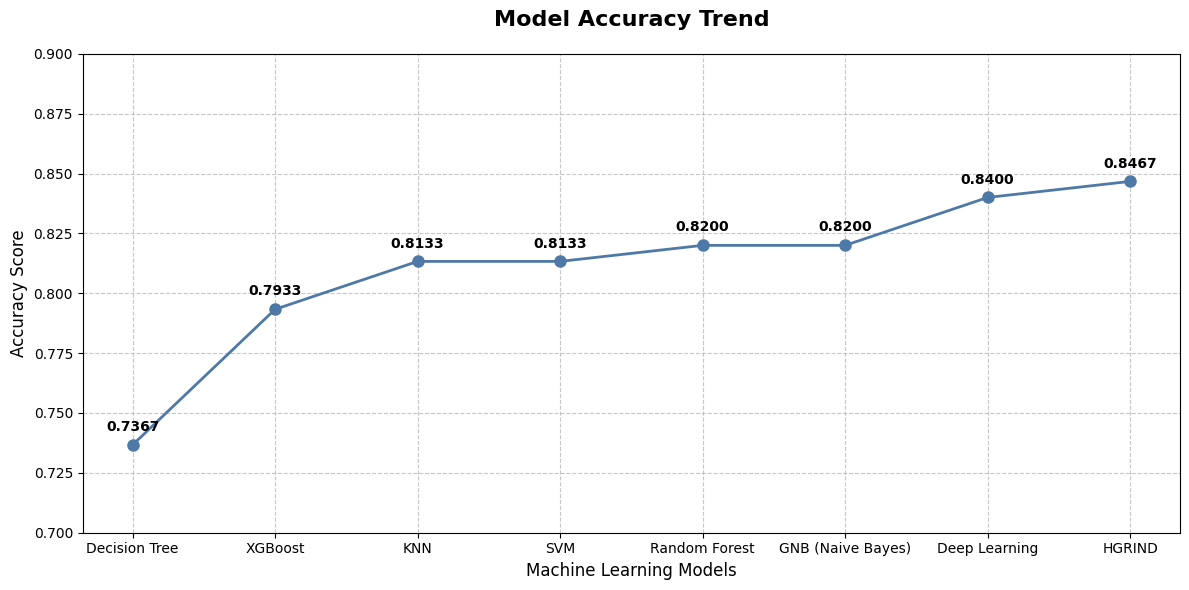

In [9]:
import matplotlib.pyplot as plt

# Data extracted from the provided model evaluations
models = [
    'HGRIND',
    'Deep Learning',
    'GNB (Naive Bayes)',
    'Random Forest',
    'SVM',
    'KNN',
    'XGBoost',
    'Decision Tree'
]

# Accuracy values from the source logs
accuracy_values = [0.8467, 0.8400, 0.8200, 0.8200, 0.8133, 0.8133, 0.7933, 0.7367]

# Reverse lists to maintain the same order as previous horizontal charts (top-performing at the top/right)
models_reversed = models[::-1]
accuracy_reversed = accuracy_values[::-1]

plt.figure(figsize=(12, 6))
plt.plot(models_reversed, accuracy_reversed, marker='o', linestyle='-', color='#4e79a7', linewidth=2, markersize=8)

# Adding labels and titles
plt.title('Model Accuracy Trend', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Accuracy Score', fontsize=12)
plt.xlabel('Machine Learning Models', fontsize=12)
plt.ylim(0.70, 0.90) # Focused range for better visibility
plt.grid(True, linestyle='--', alpha=0.7)

# Add data labels
for i, txt in enumerate(accuracy_reversed):
    plt.annotate(f'{txt:.4f}', (models_reversed[i], accuracy_reversed[i]), 
                 textcoords="offset points", xytext=(0,10), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('accuracy_line_chart.png')
plt.show()

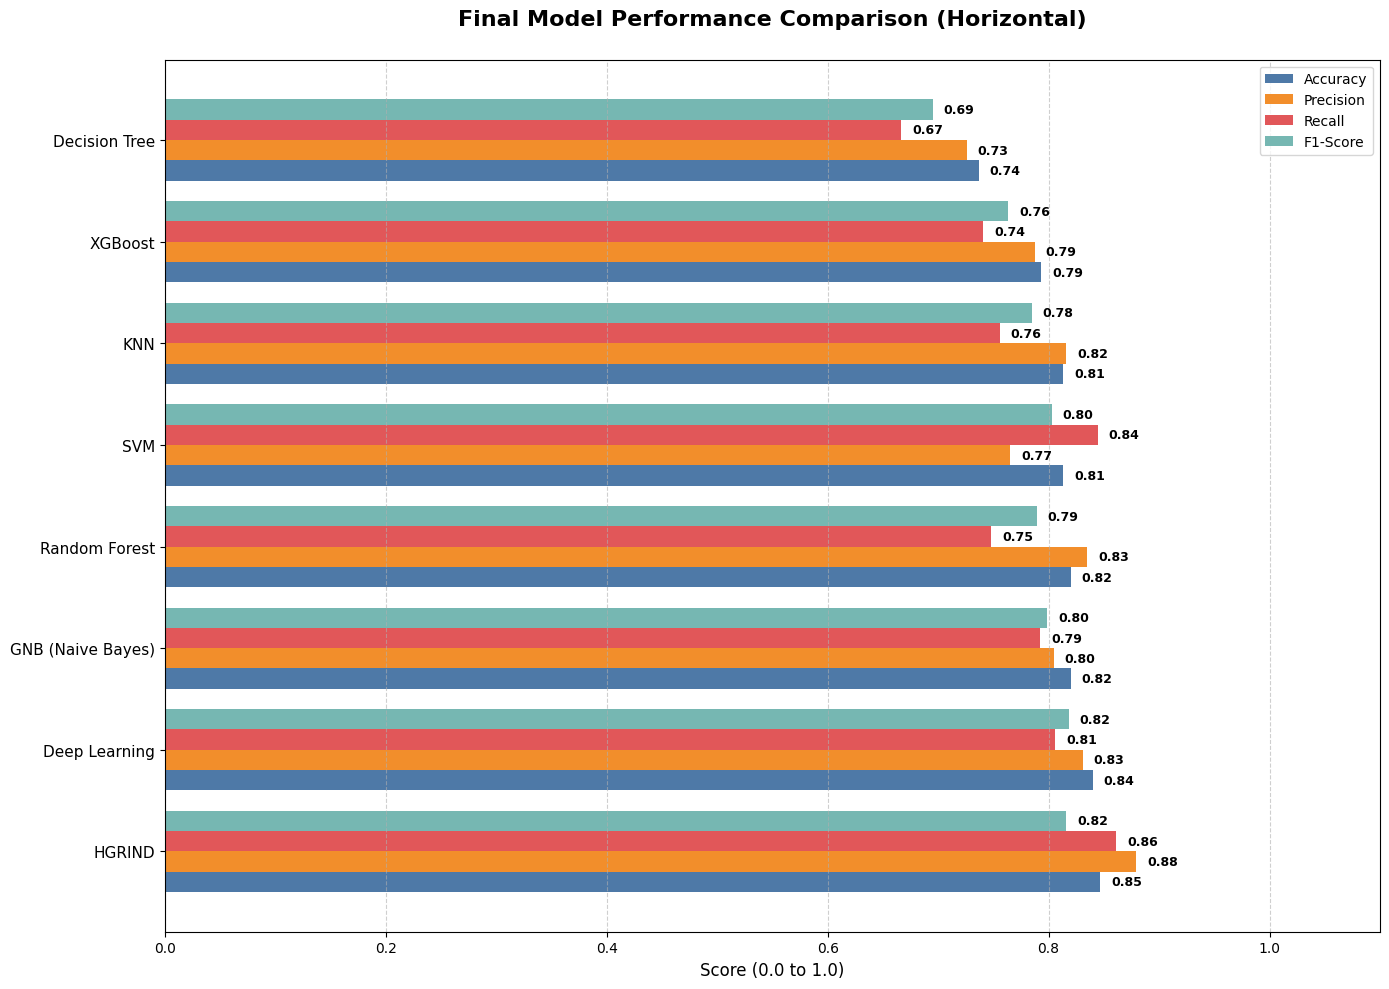

In [14]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Data consolidation from provided text logs
data = {
    'HGRIND': {'Accuracy': 0.8467, 'Precision': 0.8793, 'Recall': 0.8612, 'F1-Score': 0.8160},
    'Deep Learning': {'Accuracy': 0.8400, 'Precision': 0.8308, 'Recall': 0.8060, 'F1-Score': 0.8182},
    'GNB (Naive Bayes)': {'Accuracy': 0.8200, 'Precision': 0.8045, 'Recall': 0.7926, 'F1-Score': 0.7985},
    'Random Forest': {'Accuracy': 0.8200, 'Precision': 0.8347, 'Recall': 0.7481, 'F1-Score': 0.7891},
    'SVM': {'Accuracy': 0.8133, 'Precision': 0.7651, 'Recall': 0.8444, 'F1-Score': 0.8028},
    'KNN': {'Accuracy': 0.8133, 'Precision': 0.8160, 'Recall': 0.7556, 'F1-Score': 0.7846},
    'XGBoost': {'Accuracy': 0.7933, 'Precision': 0.7874, 'Recall': 0.7407, 'F1-Score': 0.7634},
    'Decision Tree': {'Accuracy': 0.7367, 'Precision': 0.7258, 'Recall': 0.6667, 'F1-Score': 0.6950}
}

df = pd.DataFrame(data).T

# Setup plot
fig, ax = plt.subplots(figsize=(14, 10))
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors = ['#4e79a7', '#f28e2b', '#e15759', '#76b7b2']
y = np.arange(len(df.index))
height = 0.2

# Plot horizontal bars
for i, metric in enumerate(metrics):
    bars = ax.barh(y + i * height, df[metric], height, label=metric, color=colors[i])
    # Add text labels on the bars
    for bar in bars:
        width = bar.get_width()
        ax.text(width + 0.01, bar.get_y() + bar.get_height()/2, f'{width:.2f}', 
                va='center', fontsize=9, fontweight='bold')

# Styling
ax.set_title('Final Model Performance Comparison (Horizontal)', fontsize=16, fontweight='bold', pad=25)
ax.set_xlabel('Score (0.0 to 1.0)', fontsize=12)
ax.set_yticks(y + height * 1.5)
ax.set_yticklabels(df.index, fontsize=11)
ax.set_xlim(0, 1.1)
ax.legend(loc='upper right', bbox_to_anchor=(1, 1), ncol=1, frameon=True)
ax.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('horizontal_model_comparison.png')
plt.show()

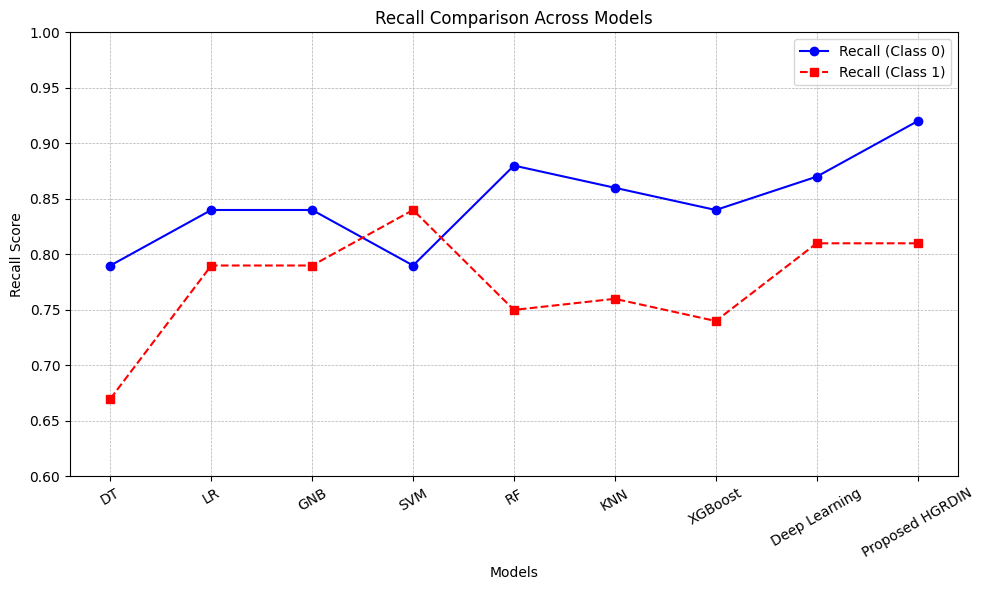

In [15]:
import matplotlib.pyplot as plt

models = ["DT", "LR", "GNB", "SVM", "RF", "KNN", "XGBoost", "Deep Learning", "Proposed HGRDIN"]

recall_0 = [0.79, 0.84, 0.84, 0.79, 0.88, 0.86, 0.84, 0.87, 0.92]
recall_1 = [0.67, 0.79, 0.79, 0.84, 0.75, 0.76, 0.74, 0.81, 0.81]

plt.figure(figsize=(10, 6), facecolor='white')

# Plot lines (keep them simple & visible)
plt.plot(models, recall_0, marker='o', linestyle='-', color='blue', label='Recall (Class 0)')
plt.plot(models, recall_1, marker='s', linestyle='--', color='red', label='Recall (Class 1)')

# Labels & title (black text)
plt.xlabel("Models", color='black')
plt.ylabel("Recall Score", color='black')
plt.title("Recall Comparison Across Models", color='black')

# Axis styling
plt.xticks(rotation=30, color='black')
plt.yticks(color='black')
plt.ylim(0.6, 1.0)

# Grid (light for clean look)
plt.grid(True, linestyle='--', linewidth=0.5)

# Legend
plt.legend()

plt.tight_layout()
plt.savefig('recall_true_negative.png')
plt.show()

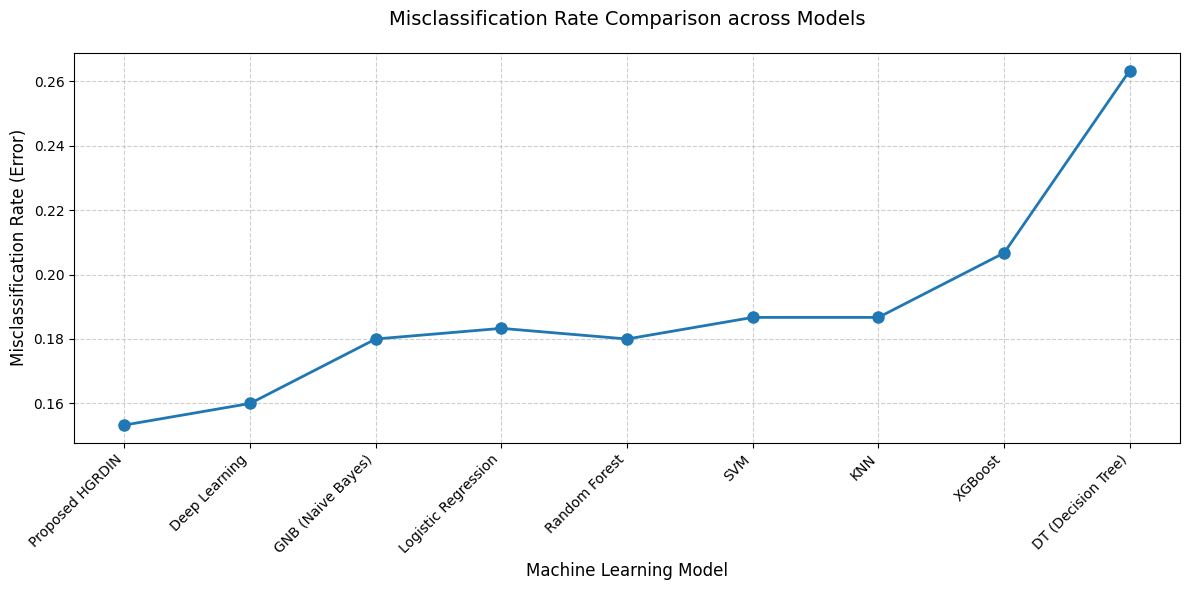

In [16]:
import matplotlib.pyplot as plt
import pandas as pd

# Data preparation
data = {
    'ML Model': ['Proposed HGRDIN', 'Deep Learning', 'GNB (Naive Bayes)', 'Logistic Regression', 
                 'Random Forest', 'SVM', 'KNN', 'XGBoost', 'DT (Decision Tree)'],
    'Accuracy': [0.8467, 0.8400, 0.8200, 0.8167, 0.8200, 0.8133, 0.8133, 0.7933, 0.7367]
}

df = pd.DataFrame(data)
df['Misclassification Rate'] = 1 - df['Accuracy']

# Set style to white background
plt.style.use('default')

plt.figure(figsize=(12, 6))
plt.plot(df['ML Model'], df['Misclassification Rate'], marker='o', linestyle='-', color='#1f77b4', linewidth=2, markersize=8)

# Formatting
plt.title('Misclassification Rate Comparison across Models', fontsize=14, pad=20)
plt.xlabel('Machine Learning Model', fontsize=12)
plt.ylabel('Misclassification Rate (Error)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

# Save the plot with a white background
plt.savefig('misclassification_rate_white.png')
plt.show()

In [ ]:
import plotly.graph_objects as go
from sklearn.metrics import auc

for model_name, data in results.items():

    fpr = data['fpr']
    tpr = data['tpr']

    # Skip invalid
    if len(fpr) == 0 or len(tpr) == 0:
        continue

    roc_auc = auc(fpr, tpr)

    # 🔥 NEW FIGURE for each model
    fig = go.Figure()

    # ROC curve
    fig.add_trace(go.Scatter(
        x=fpr,
        y=tpr,
        mode='lines',
        name=f"AUC = {roc_auc:.3f}"
    ))

    # Random line
    fig.add_trace(go.Scatter(
        x=[0, 1],
        y=[0, 1],
        mode='lines',
        line=dict(dash='dash'),
        name='Random'
    ))

    fig.update_layout(
        title=f"ROC Curve - {model_name}",
        xaxis_title="False Positive Rate",
        yaxis_title="True Positive Rate",
        width=700,
        height=500
    )
    fig.write_image(f"roc curve/ROC_Curve_{model_name}.png")
    fig.show()